In [1]:
%pip install mrcfile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.9 MB/s eta 0:00:00


In [2]:
import os
import sys
import numpy as np
import mrcfile
from PIL import Image
from sklearn.model_selection import train_test_split

In [3]:
# @title mount colab
from google.colab import drive
drive.mount('/content/drive')
print("mounted")

Mounted at /content/drive
mounted


In [4]:
# @title  { display-mode: "form" }
# @markdown Directory parameters

DATA_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/data" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/WEIGHT_MULTIPLE_TEST/rst_1" # @param {type:"string"}
TMP_DIR = "/content/tmp" # @param {type:"string"}
SOFTWARE_DIR = "/content/software" # @param {type:"string"}
WORK_DIR = os.getcwd()

!mkdir {RESULT_DIR}
!mkdir {TMP_DIR}
!mkdir {SOFTWARE_DIR}

mkdir: cannot create directory ‘/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/WEIGHT_MULTIPLE_TEST/rst_1’: File exists


In [5]:
EMPIAR_ID = "10017" # @param{type: "string"}

In [12]:
# @title  { display-mode: "form" }
denoised = "other" # @param ["other", "Topaz Denoise", "Conv CryoSegNet Denoise Process"]

denoise_prefix = ""
if denoised == "Topaz Denoise":
    denoise_prefix = "TpzD_"
if denoised == "Conv CryoSegNet Denoise Process":
    denoise_prefix = "C-CSN-D_"

# @markdown ---
extra = False # @param{type: "boolean"}
if extra == True:
    extra_prefix = "raw" # @param{type: "string"}
    denoise_prefix = denoise_prefix + extra_prefix + "_"

In [7]:
# @title  { display-mode: "form" }

TOPAZ_INSTALL = True # @param {type:"boolean"}

if TOPAZ_INSTALL:
  %cd {SOFTWARE_DIR_PATH}
  !git clone https://github.com/tbepler/topaz.git
  %cd topaz
  !pip install -e .
  %cd ..

topaz_path = os.path.join(os.getcwd(), 'topaz')
if topaz_path not in sys.path:
    sys.path.insert(0, topaz_path)

print(f"Added {topaz_path} to the Python path.")

[Errno 2] No such file or directory: '{SOFTWARE_DIR_PATH}'
/content
Cloning into 'topaz'...
remote: Enumerating objects: 3548, done.
remote: Counting objects: 100% (666/666), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 3548 (delta 627), reused 570 (delta 570), pack-reused 2882 (from 2)
Receiving objects: 100% (3548/3548), 253.12 MiB | 29.56 MiB/s, done.
Resolving deltas: 100% (2320/2320), done.
/content/topaz
Obtaining file:///content/topaz
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for topaz-em (pyproject.toml) ... done
  Created wheel for topaz-em: filename=topaz_em-0.3.17-0.editable-py3-none-any.whl size=23633 sha256=8fa65136fecaa08dc3ef741fb35bda3492c350529a8d11290477dd4ab3586838
  Stored in directory: /tmp/pip-ephem-wheel-cache-x_5akxrv/wheels/34/0d/e5/4087eebff1752f9d02379e

In [13]:
# @title  { vertical-output: true, display-mode: "form" }
# @markdown Preprocess the micrograph using topaz.
!mkdir -p {RESULT_DIR}/dataset/{EMPIAR_ID}/processed_micrographs
!topaz preprocess -v -o {TMP_DIR}/micrographs/ {DATA_DIR}/EMPIAR-{EMPIAR_ID}/{denoise_prefix}micrographs/*.mrc --device 0
!rsync -av {TMP_DIR}/micrographs/* {RESULT_DIR}/dataset/{EMPIAR_ID}/processed_micrographs/


# processed: Falcon_2012_06_12-14_33_35_0
# processed: Falcon_2012_06_12-14_57_34_0
# processed: Falcon_2012_06_12-15_07_41_0
# processed: Falcon_2012_06_12-15_14_01_0
# processed: Falcon_2012_06_12-15_17_31_0
# processed: Falcon_2012_06_12-15_27_22_0
# processed: Falcon_2012_06_12-15_30_21_0
# processed: Falcon_2012_06_12-15_33_42_0
# processed: Falcon_2012_06_12-15_36_26_0
# processed: Falcon_2012_06_12-15_41_22_0
# processed: Falcon_2012_06_12-15_43_48_0
# processed: Falcon_2012_06_12-15_46_37_0
# processed: Falcon_2012_06_12-15_53_09_0
# processed: Falcon_2012_06_12-16_26_22_0
# processed: Falcon_2012_06_12-16_44_07_0
# processed: Falcon_2012_06_12-16_48_06_0
# processed: Falcon_2012_06_12-16_51_03_0
# processed: Falcon_2012_06_12-16_55_40_0
# processed: Falcon_2012_06_12-16_59_12_0
# processed: Falcon_2012_06_12-17_02_43_0
# processed: Falcon_2012_06_12-17_14_17_0
# processed: Falcon_2012_06_12-17_17_05_0
# processed: Falcon_2012_06_12-17_23_32_0
# processed: Falcon_2012_06_12-17_

---
split

In [14]:
MRC_DIR = f'{RESULT_DIR}/dataset/{EMPIAR_ID}/processed_micrographs/'
SAVE_DIR = f"{RESULT_DIR}/dataset/{EMPIAR_ID}/processed_micrographs_np_split"

In [15]:
def save_mrc_to_npy(filenames, mrc_dir, save_dir, permissive=False):
  for filename in filenames:
    filepath = os.path.join(mrc_dir, filename)
    print("\rReading mrc:", filepath, end="", flush=True)
    with mrcfile.open(filepath, permissive=permissive) as mrc:
      basename, ext = os.path.splitext(filename)
      assert ext == ".mrc"
      print("\rConverting mrc to npy.", end="", flush=True)
      np.save(os.path.join(save_dir, basename), mrc.data)

In [16]:
# title Train test split
random_state = 1001 #@param {type:"number"}
test_size = "0.83" # @param {type:"string"}
val_size = "0.071" # @param {type:"string"}
filenames = sorted(os.listdir(MRC_DIR))

test_size = float(test_size)
if test_size and not 0<=test_size<1:
  raise ValueError(f"`test_size` should be between 0.0 and 1.0, got: {test_size}")
val_size = float(val_size)
if val_size and not 0<=val_size<1:
  raise ValueError(f"`val_size` should be between 0.0 and 1.0, got: {val_size}")
train_size = 1 - test_size - val_size
if not 0<train_size<=1:
  raise ValueError(f"`val_size` + `test_size` should be between 0.0 and 1.0, got: {test_size + val_size}")
train_filenames, test_filenames = train_test_split(filenames, test_size=test_size, train_size=train_size, random_state=random_state)
train_filenames = sorted(train_filenames)
test_filenames = sorted(test_filenames)
val_filenames = []
for filename in filenames:
  if filename not in train_filenames and filename not in test_filenames:
    val_filenames.append(filename)
print("number of files:",
  f" train:\t{len(train_filenames)}",
  f" test:\t{len(test_filenames)}",
  f" val:\t{len(val_filenames)}", sep='\n')

number of files:
 train:	8
 test:	70
 val:	6


In [17]:
%%capture --no-display
# @title Generate np file from mrc files.
# @markdown note that directory for np files should not exist


PERMISSIVE = True # @param {type:"boolean"}

try:
    os.mkdir(SAVE_DIR)
except FileExistsError:
    pass

os.mkdir(os.path.join(SAVE_DIR, "train"))
save_mrc_to_npy(train_filenames,
                mrc_dir=MRC_DIR,
                save_dir=os.path.join(SAVE_DIR, "train"),
                permissive=PERMISSIVE)
np.savetxt(os.path.join(SAVE_DIR, "train_filenames.txt"), train_filenames, fmt="%s")

os.mkdir(os.path.join(SAVE_DIR, "test"))
save_mrc_to_npy(test_filenames, mrc_dir=MRC_DIR,
                save_dir=os.path.join(SAVE_DIR, "test"),
                permissive=PERMISSIVE)
np.savetxt(os.path.join(SAVE_DIR, "test_filenames.txt"), test_filenames, fmt="%s")

os.mkdir(os.path.join(SAVE_DIR, "val"))
save_mrc_to_npy(val_filenames, mrc_dir=MRC_DIR,
                save_dir=os.path.join(SAVE_DIR, "val"),
                permissive=PERMISSIVE)
np.savetxt(os.path.join(SAVE_DIR, "val_filenames.txt"), val_filenames, fmt="%s")

In [18]:
file_path = os.path.join(SAVE_DIR, 'train_filenames.txt')
file_path2 = os.path.join(SAVE_DIR, 'val_filenames.txt')
file_path3 = os.path.join(SAVE_DIR, 'test_filenames.txt')

with open(file_path, 'r') as f:
    train_filenames = [line.strip() for line in f if line.strip()]

with open(file_path2, 'r') as f:
    val_filenames = [line.strip() for line in f if line.strip()]

with open(file_path3, 'r') as f:
    test_filenames = [line.strip() for line in f if line.strip()]

print("number of files:",
  f" train:\t{len(train_filenames)}",
  f" test:\t{len(test_filenames)}",
  f" val:\t{len(val_filenames)}", sep='\n')

number of files:
 train:	8
 test:	70
 val:	6


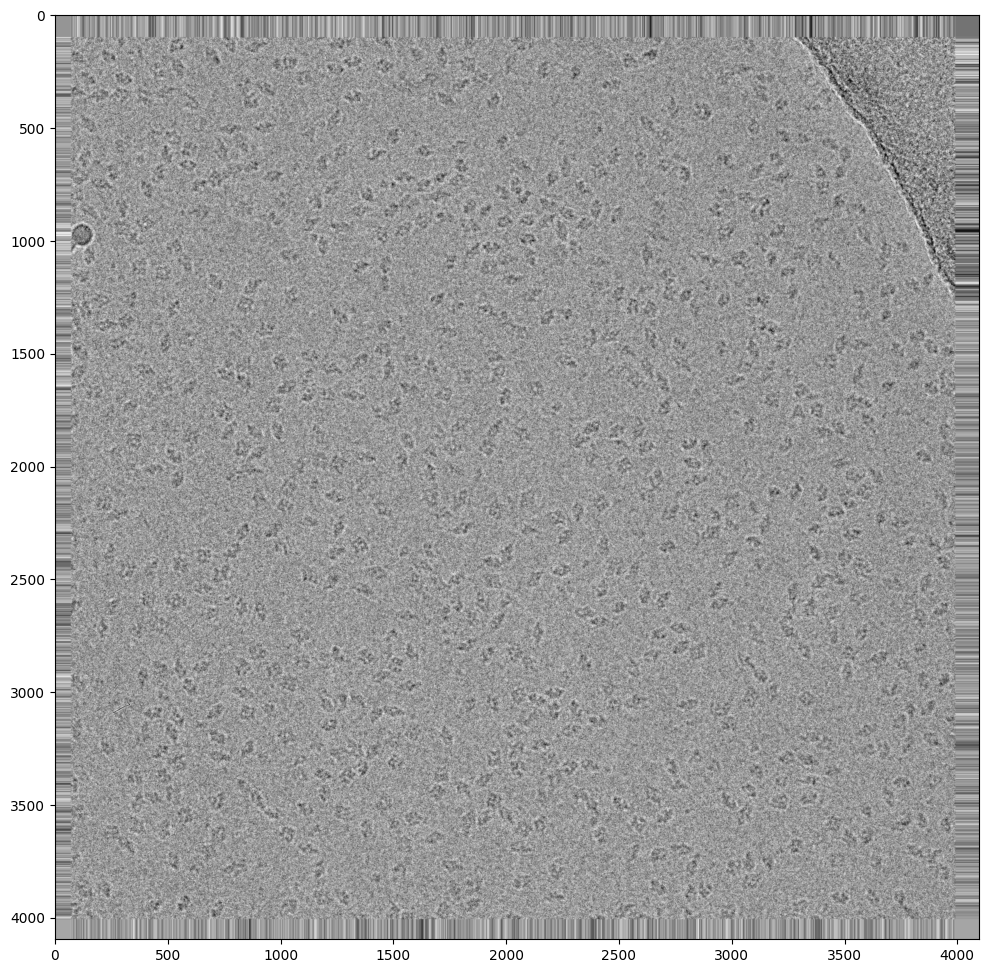

In [19]:
import matplotlib.pyplot as plt
from topaz.utils.data.loader import load_image

name = 'Falcon_2012_06_12-14_33_35_0' # @param {type: "string"}

mic = np.array(load_image(TMP_DIR + "/micrographs/" + name + '.mrc')[0], copy=False)

# scale them for visualization
mu = mic.mean()
std = mic.std()

mic = (mic - mu)/std

_,ax = plt.subplots(1,1,figsize=(24,12))

ax.imshow(mic, vmin=-4, vmax=4, cmap='Greys_r')